In [1]:
import os
from google.cloud import bigquery

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

from config import ROOT_DIR

CLIENT = bigquery.Client.from_service_account_json(os.path.join(ROOT_DIR, 'bq_credentials.json'))

def peek_df(df, nrows=5):
  print(df.shape)
  display(df.head(nrows))

In [2]:
b_m = LinearSegmentedColormap.from_list(
    "b_m",
    ["#000000", "#ff00ff"]
)

def plot_frequency_heatmap(df, date_granularity_label):
  plt.figure(figsize=(20, 10))

  sns.heatmap(df, cmap=b_m, cbar_kws={'label': f'Frequency'})

  plt.xlabel(date_granularity_label, fontsize=12)
  plt.ylabel('Triangle Opportunity', fontsize=12)
  plt.title(f'Top {df.shape[0]} Most Frequent Opportunity Triangles By {date_granularity_label}', fontsize=20)

  plt.xticks(ha='center')
  plt.yticks(rotation=0)

  plt.tight_layout()
  plt.show()

def plot_profit_heatmap(df, date_granularity_label):
  plt.figure(figsize=(20, 10))

  sns.heatmap(df, cmap=b_m, cbar_kws={'label': 'Avg Net Profit'})

  plt.xlabel(date_granularity_label, fontsize=12)
  plt.ylabel('Triangle Opportunity', fontsize=12)
  plt.title(f'Top {df.shape[0]} Most Profitable Opportunity Triangles By {date_granularity_label}', fontsize=20)

  plt.xticks(ha='center')
  plt.yticks(rotation=0)

  plt.tight_layout()
  plt.show()

## Frequency Heatmap

### Yearly

(20, 6)


/Users/alejandro/.local/share/virtualenvs/DVA_Course_Project-989PadqY/lib/python3.14/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,2017,2018,2019,2020,2021,2022
triangle_key,,,,,,
BTC|USDT|VET,0.0,410.0,4700.0,6267.0,1284.0,1221.0
BTC|SC|USDT,0.0,0.0,0.0,930.0,12005.0,929.0
BTC|FUN|USDT,0.0,0.0,288.0,2062.0,10748.0,0.0
BTC|IOST|USDT,0.0,0.0,1422.0,3358.0,4933.0,2984.0
BTC|COS|USDT,0.0,0.0,57.0,1429.0,7248.0,1125.0


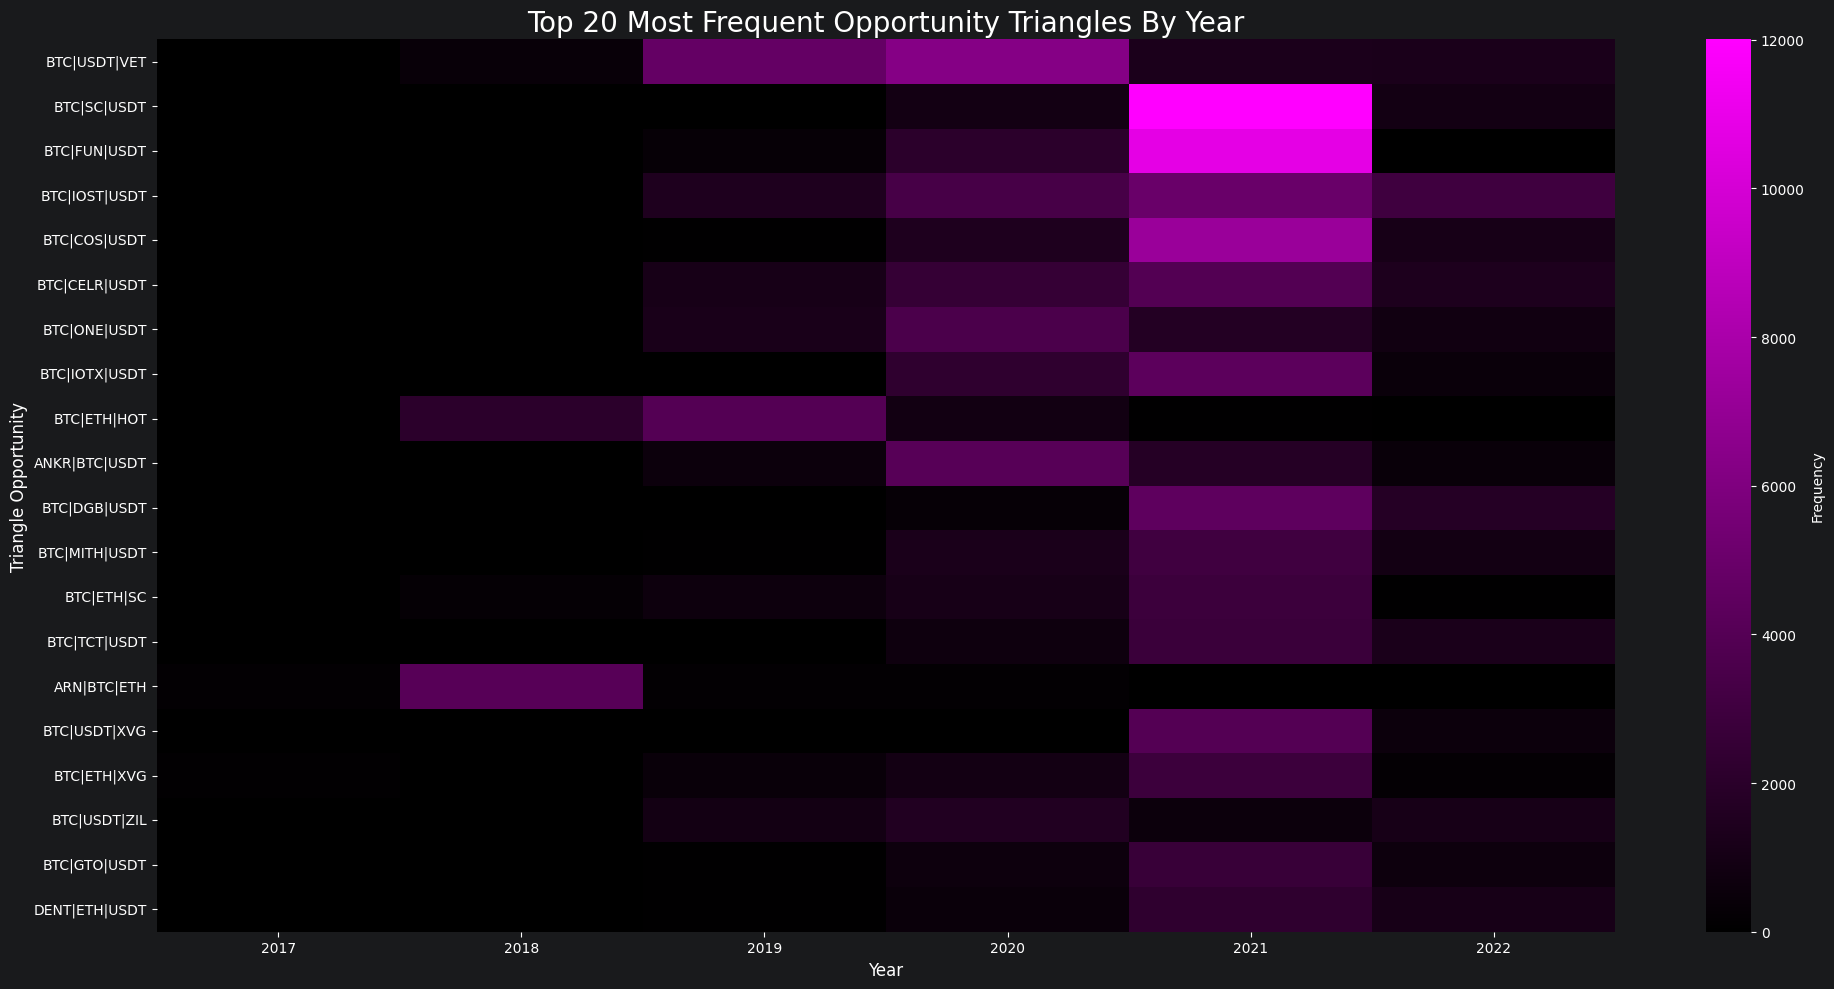

In [7]:
query = "SELECT * FROM `forward-alchemy-424420-g0.cs6242.vw_yearly_triangle_frequency_pivoted` LIMIT 20"

year_data = CLIENT.query(query).to_dataframe()
year_data = year_data.set_index('triangle_key')
year_data = year_data.astype("float64")

peek_df(year_data)
plot_frequency_heatmap(year_data, 'Year')

### Monthly

/Users/alejandro/.local/share/virtualenvs/DVA_Course_Project-989PadqY/lib/python3.14/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


(20, 12)


,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
triangle_key,,,,,,,,,,,,
BTC|USDT|VET,1496.0,1487.0,1092.0,794.0,1340.0,1494.0,759.0,592.0,629.0,728.0,1924.0,1547.0
BTC|SC|USDT,1136.0,1663.0,1118.0,1210.0,1818.0,1452.0,862.0,1401.0,1022.0,1147.0,684.0,351.0
BTC|FUN|USDT,3506.0,569.0,882.0,1004.0,694.0,393.0,482.0,2506.0,764.0,500.0,575.0,1223.0
BTC|IOST|USDT,888.0,940.0,974.0,1104.0,1509.0,1252.0,1239.0,971.0,863.0,846.0,1200.0,911.0
BTC|COS|USDT,564.0,915.0,1374.0,1384.0,1074.0,1006.0,427.0,806.0,542.0,587.0,542.0,638.0


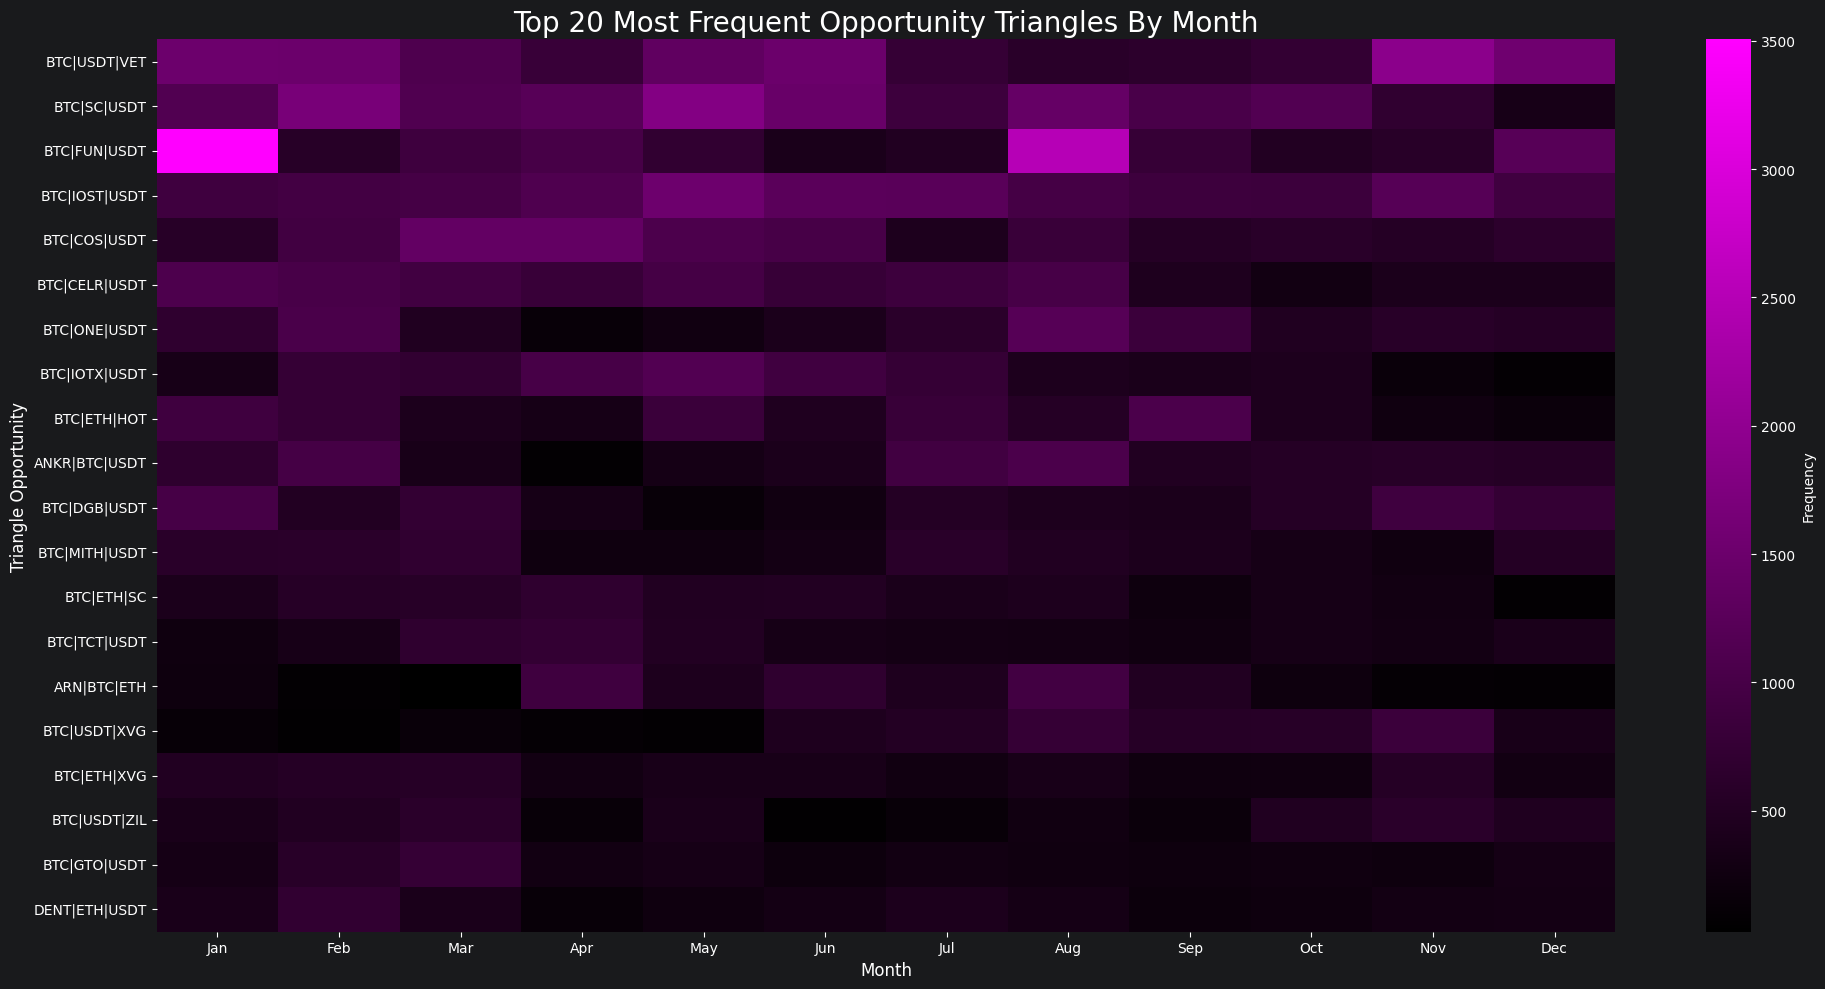

In [6]:
query = "SELECT * FROM `forward-alchemy-424420-g0.cs6242.vw_monthly_triangle_frequency_pivoted` LIMIT 20"

month_data = CLIENT.query(query).to_dataframe()
month_data = month_data.set_index('triangle_key')
month_data = month_data.astype("float64")

peek_df(month_data)
plot_frequency_heatmap(month_data, 'Month')

### Daily

/Users/alejandro/.local/share/virtualenvs/DVA_Course_Project-989PadqY/lib/python3.14/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


(20, 7)


,Mon,Tue,Wed,Thu,Fri,Sat,Sun
triangle_key,,,,,,,
BTC|USDT|VET,1835.0,2207.0,2103.0,1957.0,2105.0,1843.0,1832.0
BTC|SC|USDT,2142.0,1862.0,1927.0,2131.0,1851.0,1954.0,1997.0
BTC|FUN|USDT,1502.0,1865.0,2023.0,2165.0,2366.0,1600.0,1577.0
BTC|IOST|USDT,1834.0,1948.0,1728.0,1741.0,1986.0,1721.0,1739.0
BTC|COS|USDT,1544.0,1480.0,1236.0,1766.0,1367.0,1074.0,1392.0


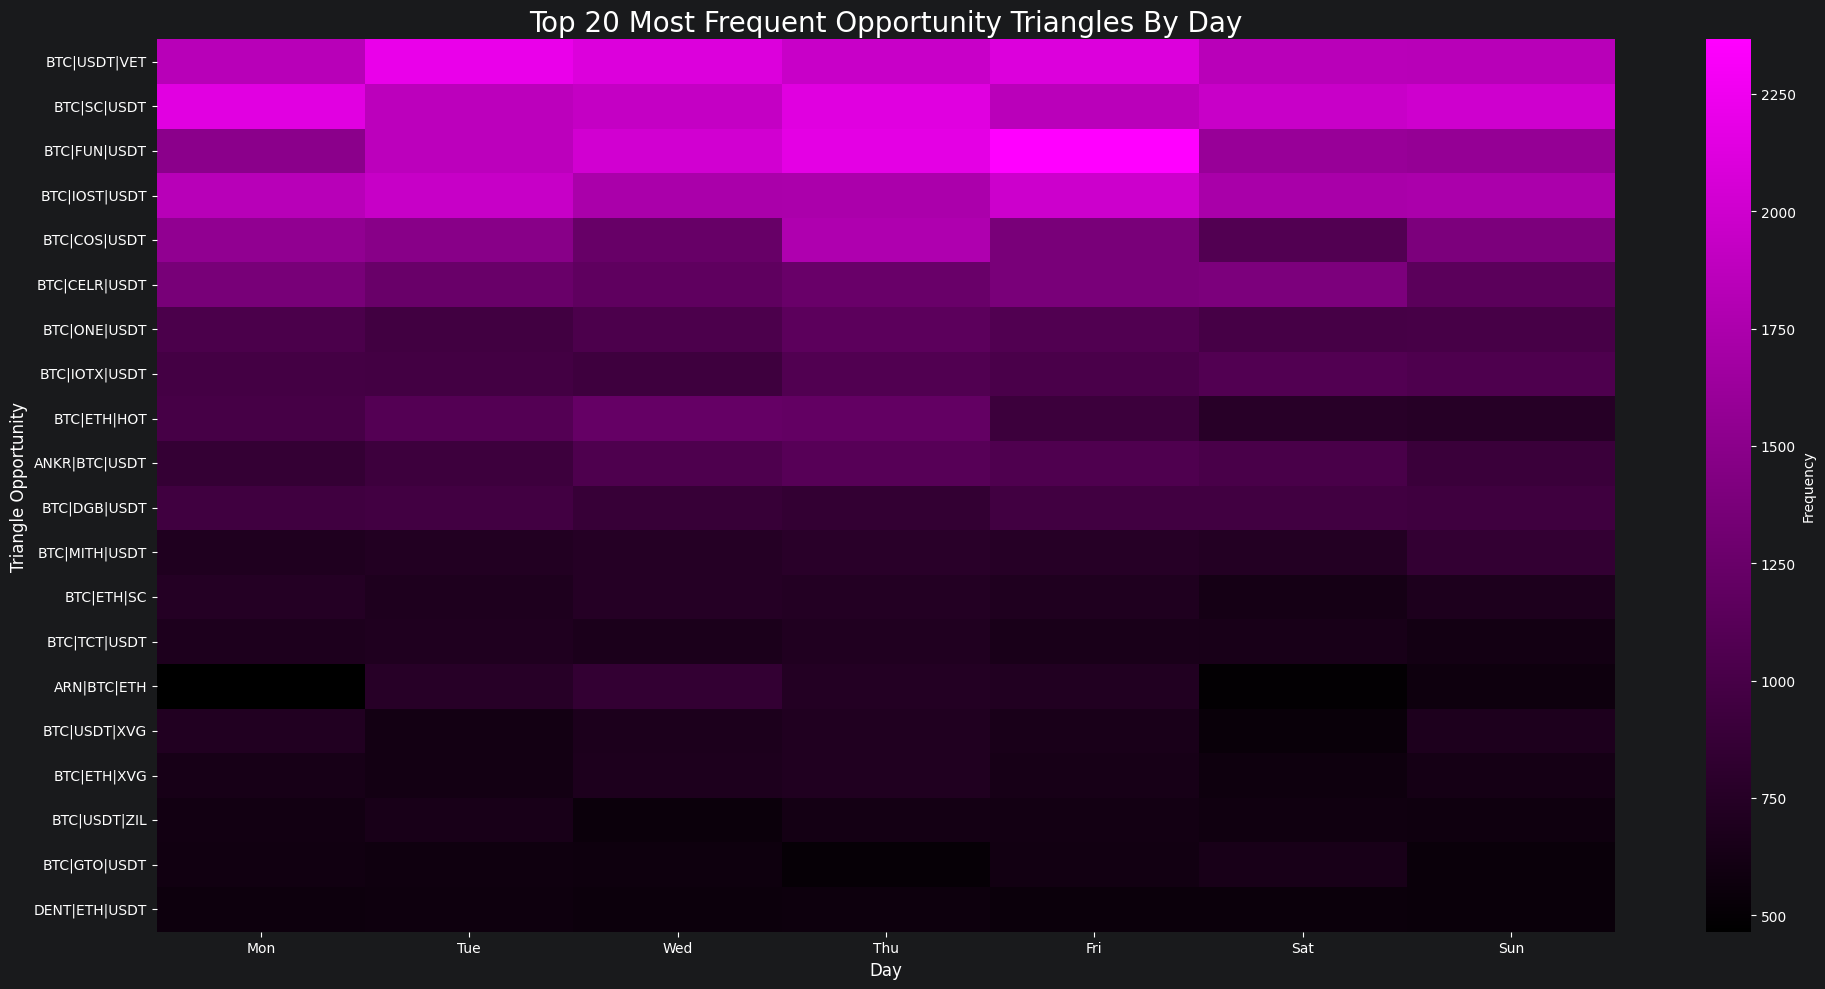

In [8]:
query = "SELECT * FROM `forward-alchemy-424420-g0.cs6242.vw_daily_triangle_frequency_pivoted` LIMIT 20"

day_data = CLIENT.query(query).to_dataframe()
day_data = day_data.set_index('triangle_key')
day_data = day_data.astype("float64")

peek_df(day_data)
plot_frequency_heatmap(day_data, 'Day')

### Hourly

/Users/alejandro/.local/share/virtualenvs/DVA_Course_Project-989PadqY/lib/python3.14/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


(20, 24)


,12AM,1AM,2AM,3AM,4AM,5AM,6AM,7AM,8AM,9AM,...,2PM,3PM,4PM,5PM,6PM,7PM,8PM,9PM,10PM,11PM
triangle_key,,,,,,,,,,,,,,,,,,,,,
BTC|USDT|VET,551.0,507.0,502.0,521.0,504.0,542.0,540.0,559.0,589.0,635.0,...,564.0,587.0,637.0,624.0,585.0,620.0,614.0,636.0,638.0,550.0
BTC|SC|USDT,515.0,648.0,1029.0,663.0,631.0,625.0,607.0,551.0,531.0,527.0,...,597.0,594.0,573.0,585.0,577.0,487.0,522.0,462.0,478.0,510.0
BTC|FUN|USDT,497.0,514.0,510.0,443.0,529.0,586.0,594.0,557.0,668.0,614.0,...,534.0,539.0,512.0,601.0,492.0,528.0,516.0,537.0,477.0,479.0
BTC|IOST|USDT,439.0,1257.0,1483.0,700.0,449.0,466.0,482.0,464.0,532.0,534.0,...,462.0,442.0,432.0,374.0,411.0,376.0,382.0,397.0,378.0,360.0
BTC|COS|USDT,365.0,351.0,309.0,295.0,301.0,315.0,420.0,399.0,456.0,473.0,...,421.0,434.0,482.0,480.0,412.0,415.0,399.0,380.0,384.0,323.0


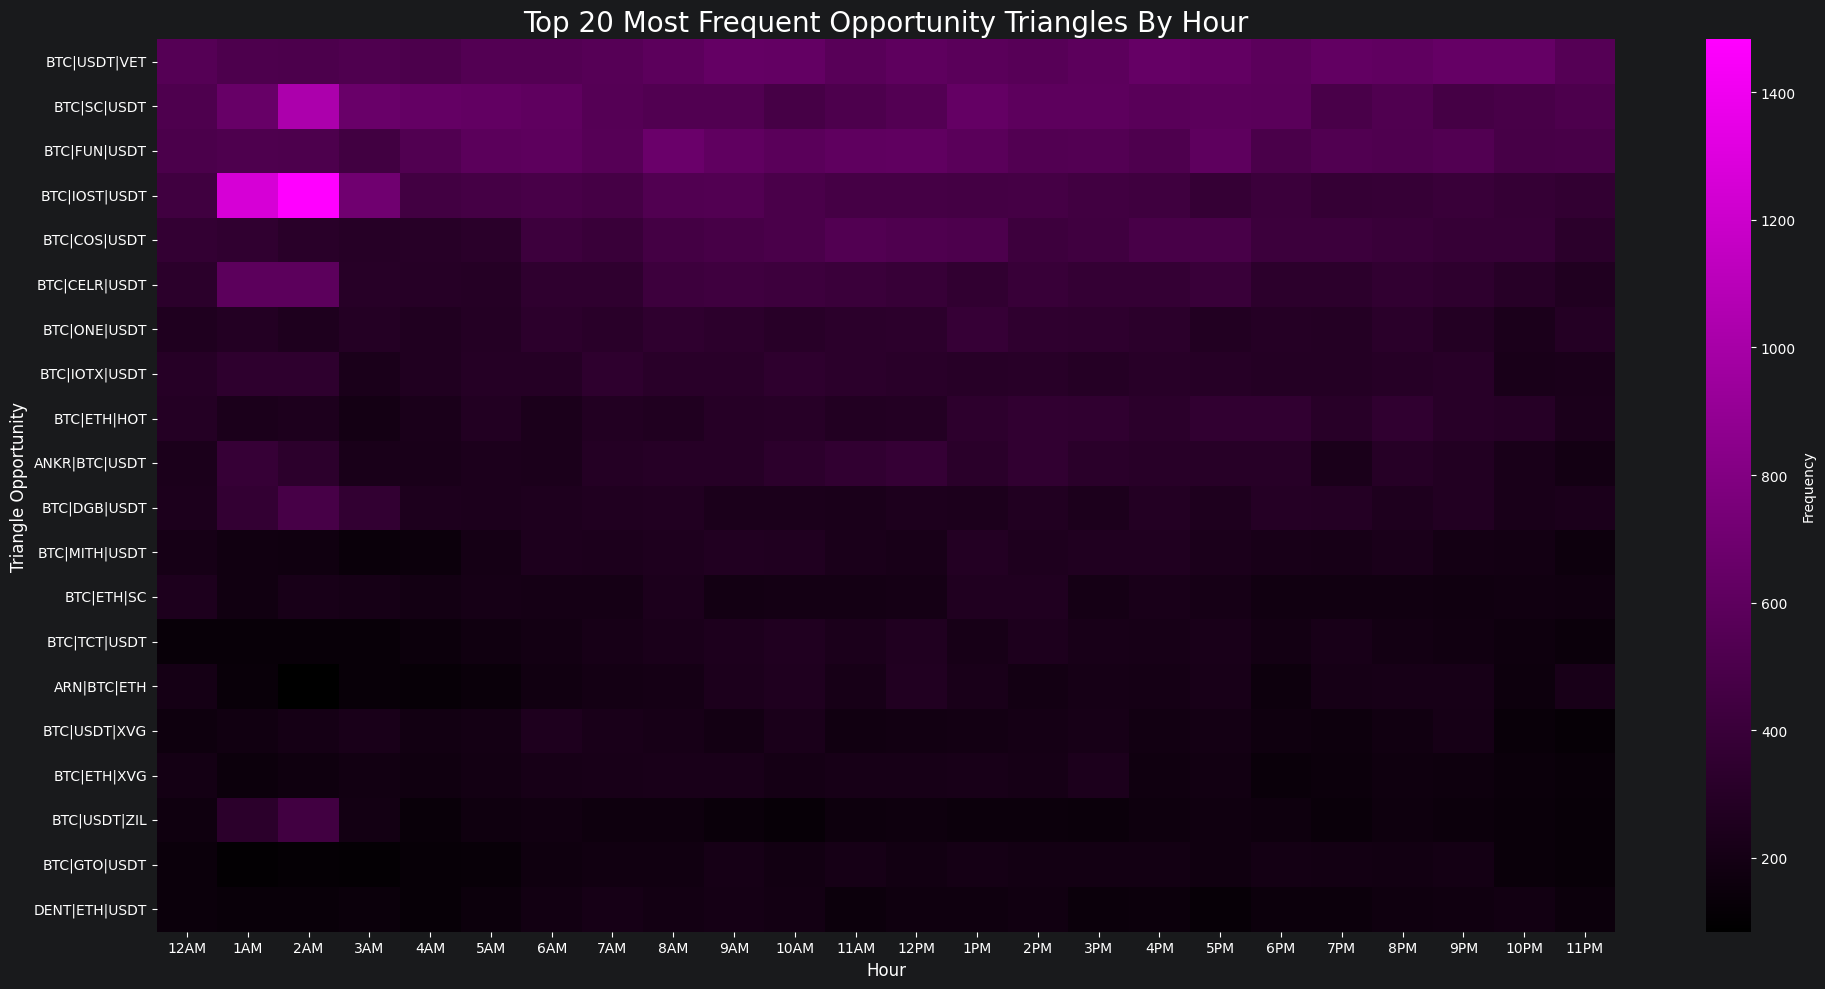

In [9]:
query = "SELECT * FROM `forward-alchemy-424420-g0.cs6242.vw_hourly_triangle_frequency_pivoted` LIMIT 20"

hour_data = CLIENT.query(query).to_dataframe()
hour_data = hour_data.set_index('triangle_key')
hour_data = hour_data.astype("float64")

peek_df(hour_data)
plot_frequency_heatmap(hour_data, 'Hour')

## Profit Heatmap

### Yearly

(20, 6)


/Users/alejandro/.local/share/virtualenvs/DVA_Course_Project-989PadqY/lib/python3.14/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,2017,2018,2019,2020,2021,2022
triangle_key,,,,,,
BNB|BTC|LUNA,0.0,0.0,0.0,0.877244,0.000000,174.154699
BTC|LUNA|USDT,0.0,0.0,0.0,0.119376,0.000000,167.344338
BTC|EUR|LUNA,0.0,0.0,0.0,0.000000,0.350479,138.064529
BTC|UNI|USDT,0.0,0.0,0.0,46.322036,0.000000,0.000000
BNB|BTC|UNI,0.0,0.0,0.0,34.386769,0.000000,0.000000


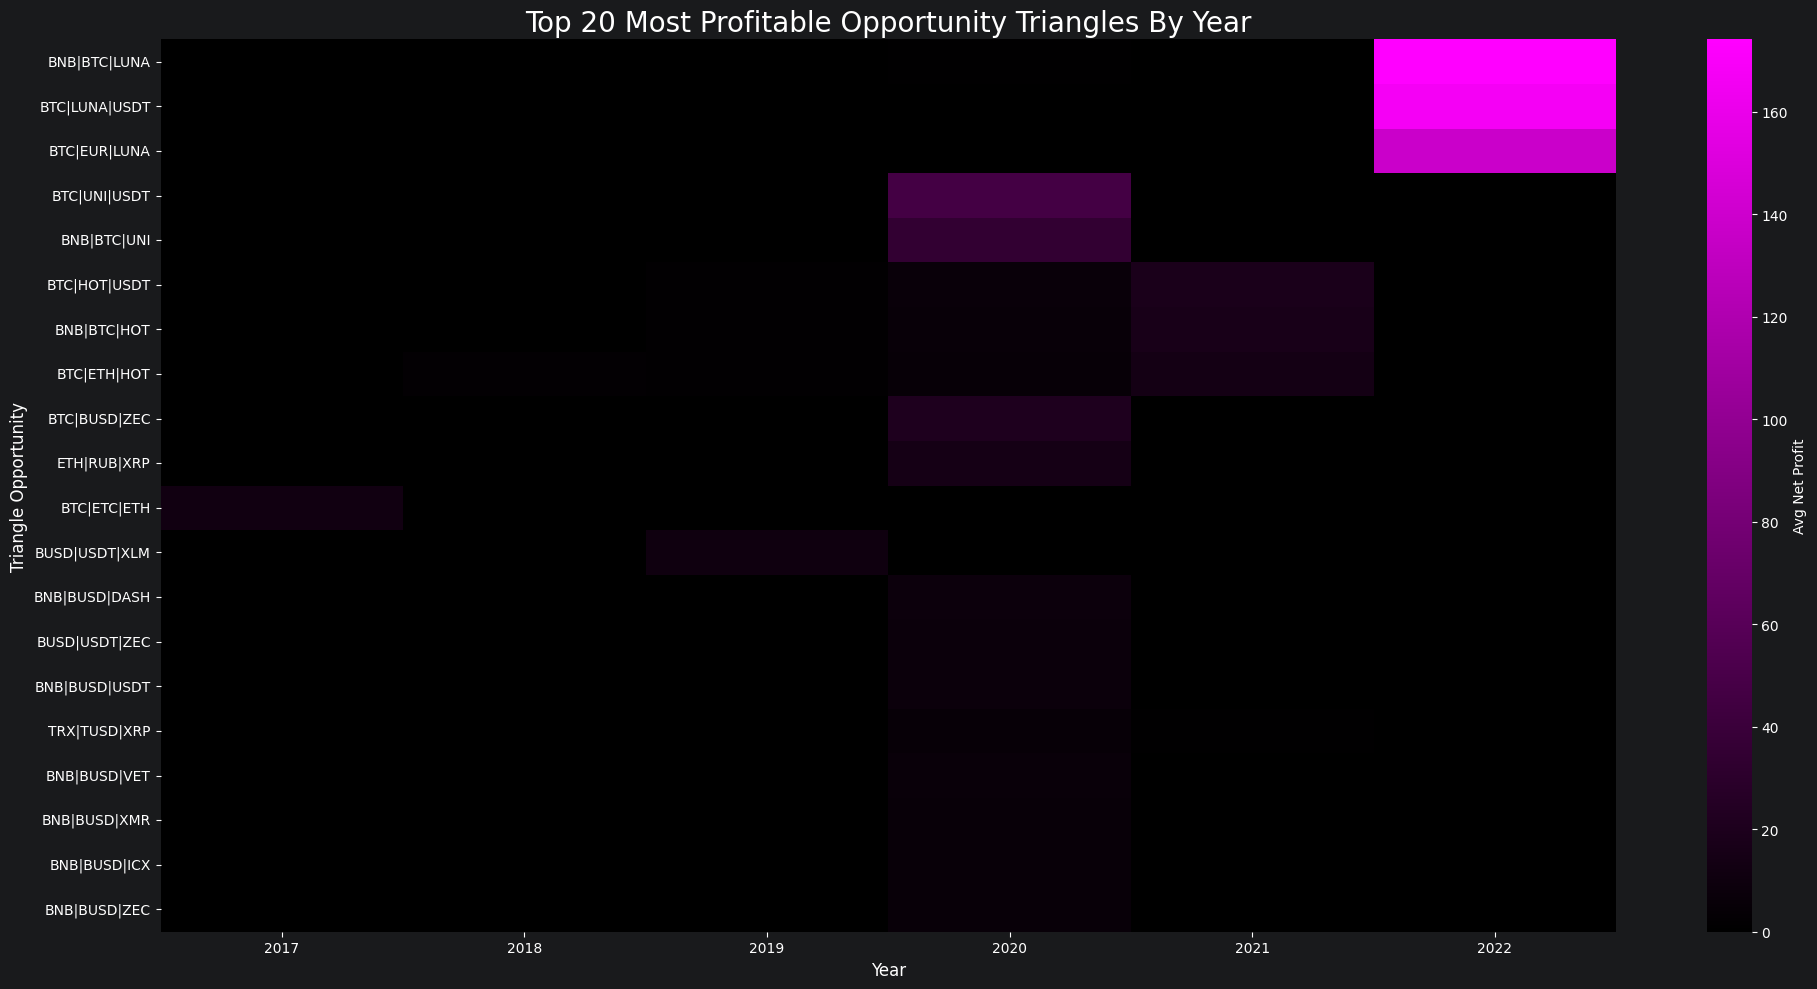

In [13]:
query = "SELECT * FROM `forward-alchemy-424420-g0.cs6242.vw_yearly_triangle_profit_pivoted` LIMIT 20"

year_data = CLIENT.query(query).to_dataframe()
year_data = year_data.set_index('triangle_key')
year_data = year_data.astype("float64")

peek_df(year_data)
plot_profit_heatmap(year_data, 'Year')

### Monthly

(20, 12)


/Users/alejandro/.local/share/virtualenvs/DVA_Course_Project-989PadqY/lib/python3.14/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
triangle_key,,,,,,,,,,,,
BTC|ETC|ETH,0.407219,0.00000,0.205198,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,192.667068,1.095196,0.326804
BNB|BTC|LUNA,0.000000,0.00000,0.000000,0.000000,174.154699,0.000000,0.000000,1.058268,0.153149,0.000000,0.000000,0.000000
BTC|LUNA|USDT,0.000000,0.00000,0.000000,0.000000,167.344338,0.000000,0.000000,0.119376,0.000000,0.000000,0.000000,0.000000
BTC|EUR|LUNA,0.000000,0.00000,0.000000,0.000000,118.391094,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
BTC|HOT|USDT,16.803593,3.42442,1.464945,1.649347,2.486681,2.289944,4.350579,5.532912,5.951587,4.198123,7.974775,10.937591


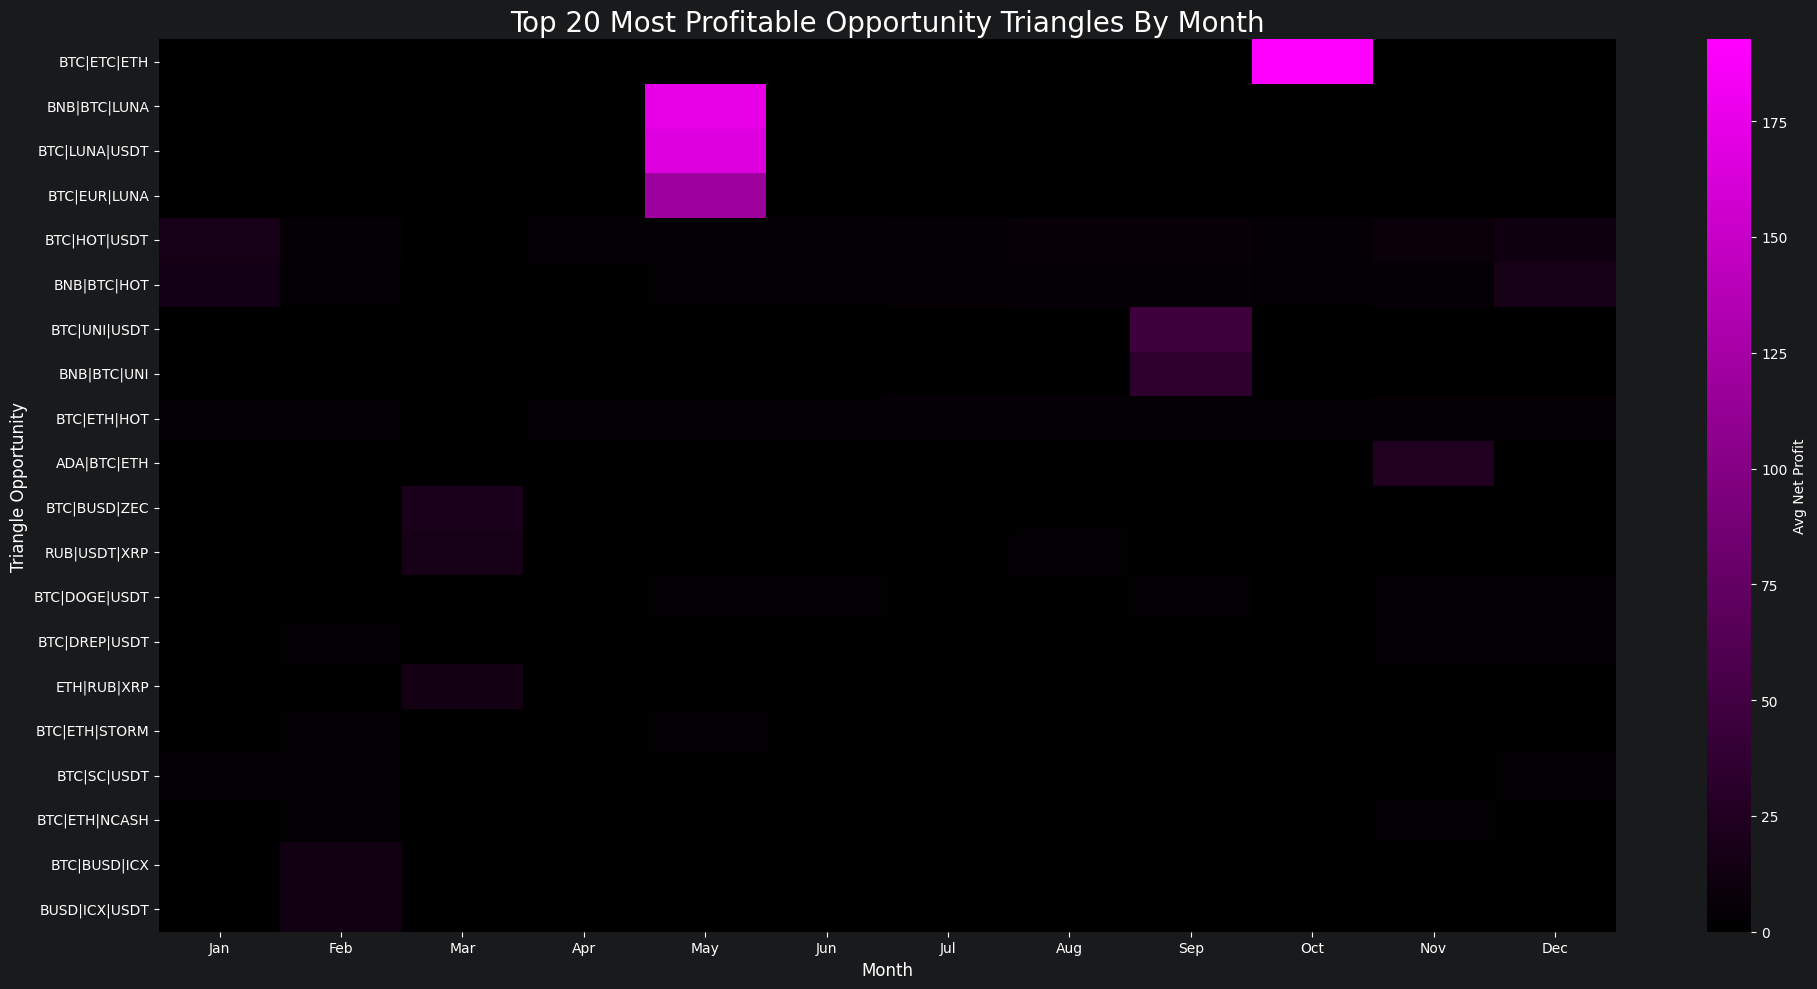

In [14]:
query = "SELECT * FROM `forward-alchemy-424420-g0.cs6242.vw_monthly_triangle_profit_pivoted` LIMIT 20"

month_data = CLIENT.query(query).to_dataframe()
month_data = month_data.set_index('triangle_key')
month_data = month_data.astype("float64")

peek_df(month_data)
plot_profit_heatmap(month_data, 'Month')

### Daily

/Users/alejandro/.local/share/virtualenvs/DVA_Course_Project-989PadqY/lib/python3.14/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


(20, 7)


,Mon,Tue,Wed,Thu,Fri,Sat,Sun
triangle_key,,,,,,,
BTC|LUNA|USDT,0.119376,0.000000,0.000000,7.751943,190.987655,0.000000,0.000000
BNB|BTC|LUNA,0.000000,0.000000,1.858997,4.011868,173.671833,0.000000,0.000000
BTC|EUR|LUNA,0.000000,0.000000,0.000000,2.483240,158.586352,0.000000,0.577201
BTC|ETC|ETH,0.517570,0.553434,0.379286,0.476334,77.180519,0.450303,1.677908
BTC|UNI|USDT,0.000000,0.000000,0.000000,46.322036,0.000000,0.000000,0.000000


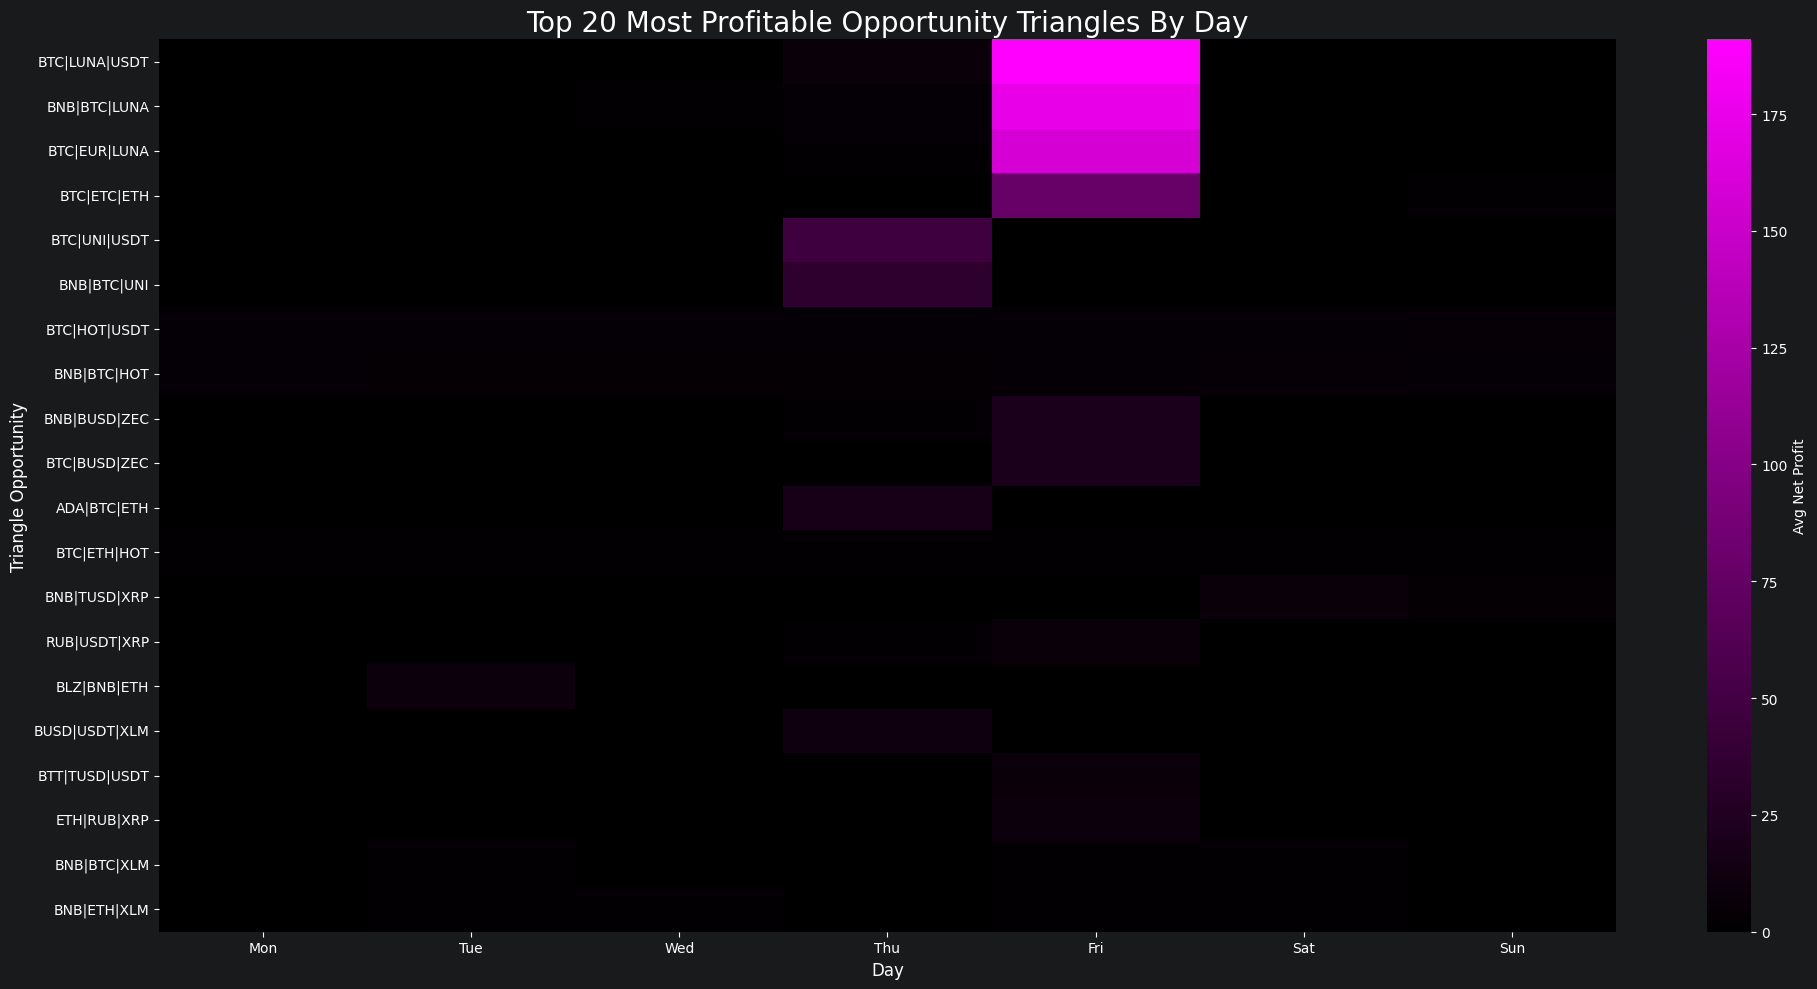

In [15]:
query = "SELECT * FROM `forward-alchemy-424420-g0.cs6242.vw_daily_triangle_profit_pivoted` LIMIT 20"

day_data = CLIENT.query(query).to_dataframe()
day_data = day_data.set_index('triangle_key')
day_data = day_data.astype("float64")

peek_df(day_data)
plot_profit_heatmap(day_data, 'Day')

### Hourly

(20, 24)


/Users/alejandro/.local/share/virtualenvs/DVA_Course_Project-989PadqY/lib/python3.14/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,12AM,1AM,2AM,3AM,4AM,5AM,6AM,7AM,8AM,9AM,...,2PM,3PM,4PM,5PM,6PM,7PM,8PM,9PM,10PM,11PM
triangle_key,,,,,,,,,,,,,,,,,,,,,
BTC|ETC|ETH,0.695058,0.369630,0.430605,0.588529,0.647038,0.247023,0.586751,0.532097,0.250551,0.749399,...,0.909892,1.048335,0.888387,2.060330,3.438321,0.448779,0.905847,287.733542,0.333630,0.375220
BNB|BTC|LUNA,194.494876,0.000000,0.000000,0.000000,0.159268,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.126997,0.000000,2.087810,0.000000,0.000000,0.000000,0.000000,0.000000,4.317719,4.820971
BTC|LUNA|USDT,190.987655,0.000000,0.000000,0.000000,0.119376,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.060201,8.649191
BTC|EUR|LUNA,158.586352,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.223542,0.000000,0.000000,0.344400,0.000000,0.354139,0.000000,0.787997,5.719017
BTC|HOT|USDT,3.588909,3.299427,4.649779,3.858696,3.770779,3.454165,3.699314,4.405685,5.440994,5.199736,...,5.455519,4.189863,3.739562,4.069605,3.817613,4.242543,4.301286,3.893370,3.428053,2.744655


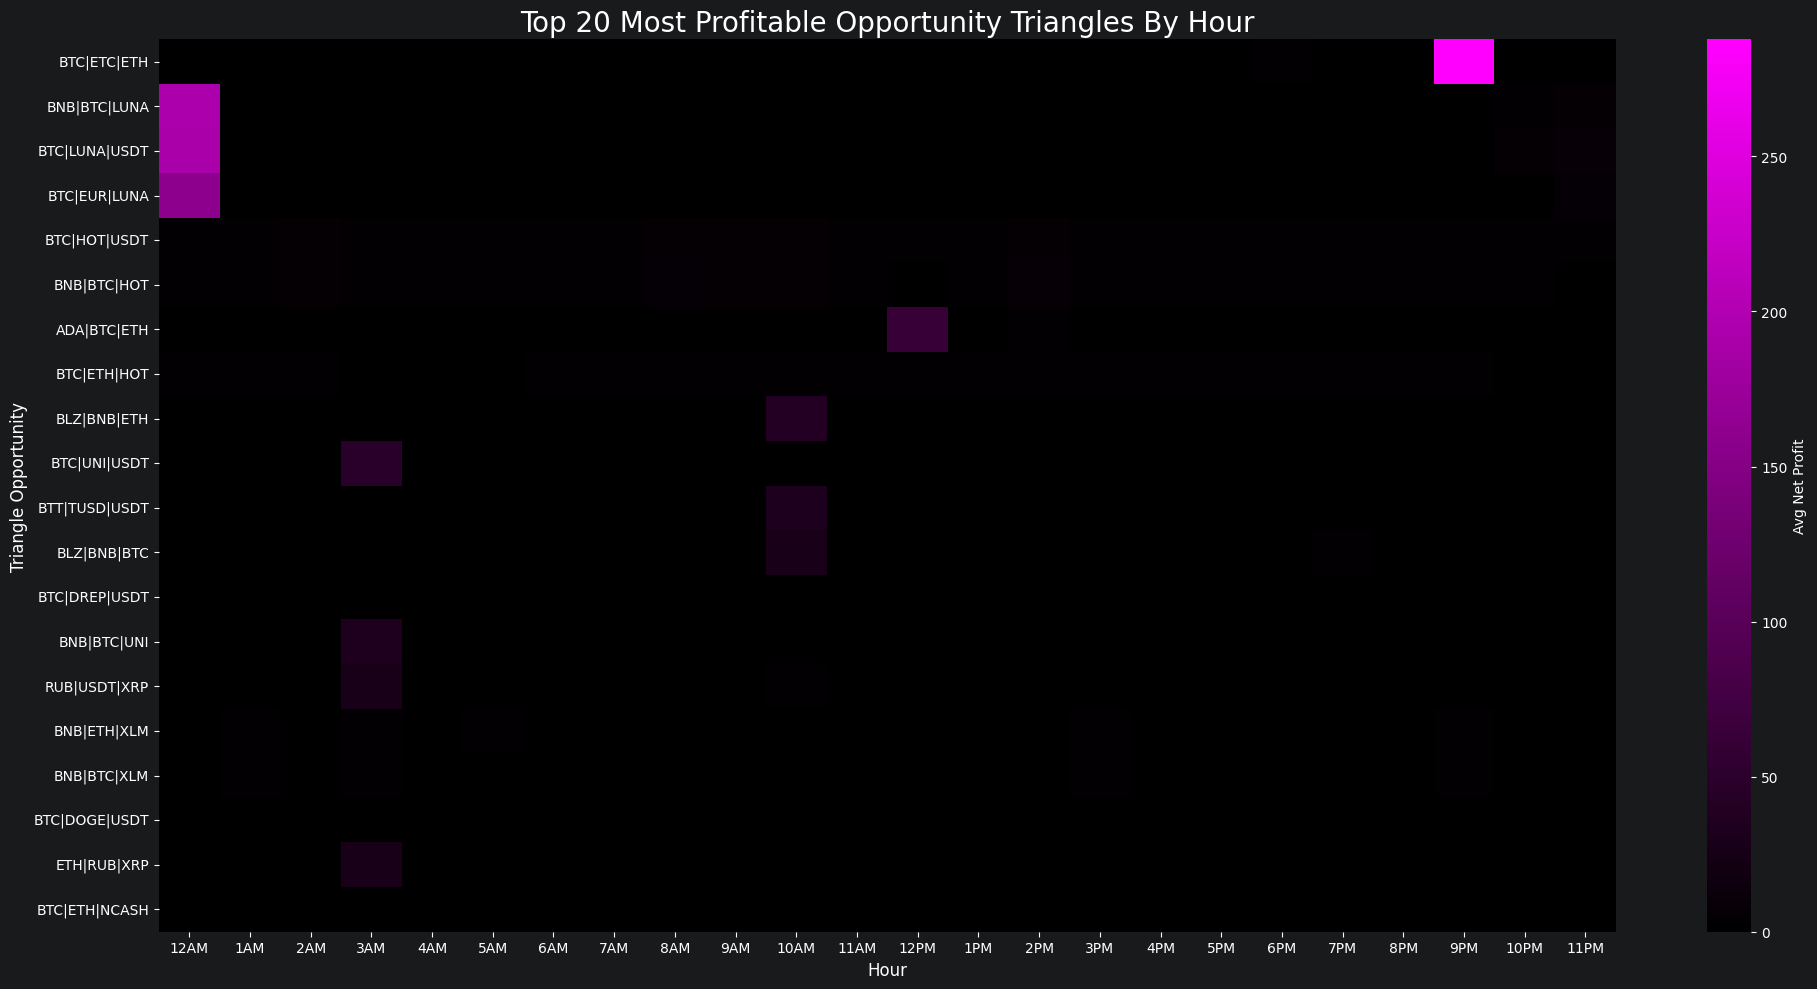

In [16]:
query = "SELECT * FROM `forward-alchemy-424420-g0.cs6242.vw_hourly_triangle_profit_pivoted` LIMIT 20"

hour_data = CLIENT.query(query).to_dataframe()
hour_data = hour_data.set_index('triangle_key')
hour_data = hour_data.astype("float64")

peek_df(hour_data)
plot_profit_heatmap(hour_data, 'Hour')